### 장애 허용

장애 허용(Fault Tolerance)은 장애가 발생했을 때 오류를 처리하거나 복구하여 작업을 계속하거나 재개할 수 있게 하는 능력이다.

In [1]:
from IPython.display import Image, display

from typing import TypedDict

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, RetryPolicy

### `RetryPolicy`로 자동 재시도하기

외부 서비스에 일시적으로 연결되지 않다가 다시 시도하면 성공하는 상황을 살펴보자.

노드에 `RetryPolicy`를 설정하면 지정한 오류가 발생했을 때 **한 번의 그래프 호출 안에서** 해당 노드를 자동으로 재시도한다.

| 설정 | 의미 |
|---|---|
| `initial_interval` | 첫 재시도 전 대기 시간 |
| `backoff_factor` | 대기 시간 증가 배수 |
| `max_interval` | 최대 대기 시간 |
| `max_attempts` | 최초 실행을 포함한 최대 시도 횟수 |
| `jitter` | 무작위 지연 적용 여부 |
| `retry_on` | 재시도할 예외 타입 또는 판별 함수 |

`prepare → call_service`로 연결하고, `call_service`가 두 번 실패한 뒤 성공하도록 구성한다.

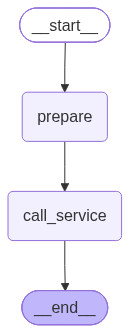

In [ ]:
class RetryState(TypedDict):
    query: str
    prepared_query: str
    response: str


retry_count = {"prepare": 0, "call_service": 0}


def retry_prepare(state: RetryState):
    retry_count["prepare"] += 1
    print("prepare 실행: 조회 요청 준비")
    return {"prepared_query": state["query"].strip()}


def call_unstable_service(state: RetryState):
    retry_count["call_service"] += 1
    attempt = retry_count["call_service"]
    print(f"call_service 시도 {attempt}")
    if attempt < 3:
        print(f"call_service 시도 {attempt} 실패: 일시적 연결 오류")
        raise ConnectionError("일시적 연결 오류")
    return {"response": f"조회 성공: {state['prepared_query']}"}


retry_policy = RetryPolicy(
    initial_interval=1.0, 
    backoff_factor=1.0, 
    max_interval=1.0,
    max_attempts=3, 
    jitter=True, 
    retry_on=ConnectionError,
)

retry_builder = StateGraph(RetryState)
retry_builder.add_node("prepare", retry_prepare)
retry_builder.add_node("call_service", call_unstable_service, retry_policy=retry_policy)
retry_builder.add_edge(START, "prepare")
retry_builder.add_edge("prepare", "call_service")
retry_builder.add_edge("call_service", END)
retry_graph = retry_builder.compile()

display(Image(retry_graph.get_graph().draw_mermaid_png()))

In [3]:
retry_result = retry_graph.invoke({"query": "배송 현황"})
print(retry_result["response"])
print("노드별 실행 횟수:", retry_count)

prepare 실행: 조회 요청 준비
call_service 시도 1
call_service 시도 1 실패: 일시적 연결 오류
call_service 시도 2
call_service 시도 2 실패: 일시적 연결 오류
call_service 시도 3
조회 성공: 배송 현황
노드별 실행 횟수: {'prepare': 1, 'call_service': 3}


노드별 실행 횟수가 `prepare=1`, `call_service=3`인지 확인한다. **실패한 `call_service`만 재시도되고, 완료된 `prepare`는 다시 실행되지 않는다.**

### 최대 시도 횟수까지 실패하기

정해진 횟수만큼 시도해도 연결 오류가 계속되는 상황을 살펴보자. 

재시도 횟수를 소진하면 `invoke()`에서 예외가 발생한다.

In [4]:
retry_count = {"prepare": 0, "call_service": 0}

limited_retry_policy = RetryPolicy(
    initial_interval=1.0, backoff_factor=1.0, max_interval=1.0,
    max_attempts=2, jitter=True, retry_on=ConnectionError,
)

limited_retry_builder = StateGraph(RetryState)
limited_retry_builder.add_node("prepare", retry_prepare)
limited_retry_builder.add_node(
    "call_service", call_unstable_service, retry_policy=limited_retry_policy
)
limited_retry_builder.add_edge(START, "prepare")
limited_retry_builder.add_edge("prepare", "call_service")
limited_retry_builder.add_edge("call_service", END)
limited_retry_graph = limited_retry_builder.compile()

In [5]:
try:
    limited_retry_graph.invoke({"query": "배송 현황"})
except ConnectionError as error:
    print("최대 시도 횟수 후 실행 실패:", error)
print("노드별 실행 횟수:", retry_count)

prepare 실행: 조회 요청 준비
call_service 시도 1
call_service 시도 1 실패: 일시적 연결 오류
call_service 시도 2
call_service 시도 2 실패: 일시적 연결 오류
최대 시도 횟수 후 실행 실패: 일시적 연결 오류
노드별 실행 횟수: {'prepare': 1, 'call_service': 2}


성공 메시지 없이 최종 실패 메시지가 출력되고, 실행 횟수는 `prepare=1`, `call_service=2`인지 확인한다. 실패한 노드만 두 번 시도한 뒤 예외가 호출 코드로 전달된 것이다.

### 재시도하지 않을 오류 구분하기

요청 형식이 잘못되어 같은 요청을 반복해도 처리할 수 없는 상황을 살펴보자.

`retry_on=ConnectionError` 정책을 사용하고, `validate` 노드에서 `ValueError`를 발생시킨다.

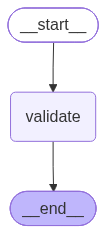

In [6]:
permanent_count = {"attempts": 0}


def reject_invalid_input(state: RetryState):
    permanent_count["attempts"] += 1
    raise ValueError("잘못된 요청 형식")


permanent_builder = StateGraph(RetryState)
permanent_builder.add_node("validate", reject_invalid_input, retry_policy=retry_policy)
permanent_builder.add_edge(START, "validate")
permanent_builder.add_edge("validate", END)
permanent_graph = permanent_builder.compile()

display(Image(permanent_graph.get_graph().draw_mermaid_png()))

In [7]:
try:
    permanent_graph.invoke({"query": "잘못된 요청"})
except ValueError as error:
    print(f"실행 실패: {error}")
print("총 시도 횟수:", permanent_count["attempts"])

실행 실패: 잘못된 요청 형식
총 시도 횟수: 1


총 시도 횟수가 `1`이고 `ValueError`의 메시지가 출력되는지 확인한다.

노드가 오류를 발생시키지 않고 `{"status": "failed"}`를 반환하면 정상 반환이므로 `RetryPolicy`가 동작하지 않는다.

### 체인의 재시도·대체 실행과 비교

| 방식 | 오류가 발생했을 때의 동작 |
|---|---|
| `RetryPolicy` | 노드 단위로 다시 실행한다. |
| `with_retry()` | Runnable 단위로 다시 실행한다. |
| `with_fallbacks()` | 지정한 다른 모델이나 체인으로 바꾸어 실행한다. |

재시도는 **실패할 가능성이 있고, 다시 실행할 필요가 있는 가장 작은 단위**에 적용한다. 노드 전체를 다시 실행해야 하면 `RetryPolicy`, 노드 안의 모델 호출만 다시 실행하면 된다면 `model.with_retry()`를 선택한다.

### 노드 실행 실패와 재개

자동 재시도로도 해결되지 않아 실행이 실패로 끝난 뒤, 원인을 해결하고 작업을 이어서 처리하는 상황을 살펴보자.

실패 원인을 해결한 뒤 같은 `thread_id`로 `invoke(None, config)`를 호출하면 저장된 실행을 이어서 진행한다. `None`은 새 입력이 없다는 뜻이며, 재개할 노드는 checkpoint의 `next`에서 확인한다.

### super-step

super-step은 그래프에서 같은 차례에 실행하도록 예정된 노드들의 묶음이다. checkpointer를 설정하면 각 super-step이 완료될 때 노드들의 반환값을 반영한 State가 checkpoint로 저장된다.

```text
순차 실행: prepare → call_service → finish
병렬 실행: prepare → [stable_branch, unstable_branch] → summarize
```

순차 실행에서는 각 노드가 서로 다른 super-step에 속하므로 노드마다 완료 후 checkpoint가 만들어진다. 병렬 실행에서는 대괄호 안의 두 노드가 같은 super-step에 속하므로 두 노드가 모두 완료된 뒤 checkpoint가 만들어진다.

### 순차 실행 재개하기

`sequential_gate["allow_service"]`가 `False`이면 연결 실패로 예외가 발생하고, `True`이면 연결이 복구되어 정상 처리된다. 카운터로 각 노드의 실행 횟수를 기록한다.

같은 실험을 처음부터 반복할 때는 카운터·gate 초기화와 그래프 생성 셀부터 다시 실행한다.

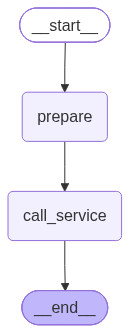

In [14]:
class SequentialState(TypedDict):
    request: str
    prepared: str
    response: str


sequential_count = {"prepare": 0, "call_service": 0}
sequential_gate = {"allow_service": False}


def sequential_prepare(state: SequentialState):
    sequential_count["prepare"] += 1
    return {"prepared": state["request"].strip()}


def sequential_call_service(state: SequentialState):
    sequential_count["call_service"] += 1
    if not sequential_gate["allow_service"]:
        raise ConnectionError("서비스 연결 실패")
    return {"response": f"처리 완료: {state['prepared']}"}


sequential_builder = StateGraph(SequentialState)
sequential_builder.add_node("prepare", sequential_prepare)
sequential_builder.add_node("call_service", sequential_call_service)
sequential_builder.add_edge(START, "prepare")
sequential_builder.add_edge("prepare", "call_service")
sequential_builder.add_edge("call_service", END)
sequential_graph = sequential_builder.compile(checkpointer=InMemorySaver())
sequential_config = {"configurable": {"thread_id": "fault-sequential-1"}}

display(Image(sequential_graph.get_graph().draw_mermaid_png()))

### 첫 호출에서 실패시키기

`prepare`는 완료되고 `call_service`는 연결 오류로 실패한다.

In [15]:
try:
    sequential_graph.invoke({"request": "주문 확인"}, sequential_config)
except ConnectionError as error:
    print("실행 실패:", error)

실행 실패: 서비스 연결 실패


### 재개할 노드 확인하기

저장된 State에 `prepared`가 있고, `next`가 `call_service`인지 확인한다.

In [16]:
sequential_snapshot = sequential_graph.get_state(sequential_config)
print("저장된 State:", sequential_snapshot.values)
print("다음 노드:", sequential_snapshot.next)

저장된 State: {'request': '주문 확인', 'prepared': '주문 확인'}
다음 노드: ('call_service',)


### 같은 thread에서 재개하기

`sequential_gate["allow_service"] = True`로 연결이 복구된 상황을 만든 뒤, 같은 `thread_id`로 `invoke(None, config)`를 호출한다.

In [17]:
sequential_gate["allow_service"] = True
sequential_result = sequential_graph.invoke(None, sequential_config)
print("재개 결과:", sequential_result["response"])
print("호출 횟수:", sequential_count)

재개 결과: 처리 완료: 주문 확인
호출 횟수: {'prepare': 1, 'call_service': 2}


호출 횟수가 `prepare=1`, `call_service=2`인지 확인한다. 완료된 준비 노드는 반복하지 않고 실패한 서비스 호출 노드만 처음부터 다시 실행한 것이다.

### 재개는 누가 요청하는가?

재개 요청은 사용자나 프로그램이 보낼 수 있다.

- **사용자 요청**: ‘다시 시도’ 버튼을 누르면 서버가 해당 작업을 재개한다.
- **자동 재개**: 실패한 작업을 기록해 두고, 일정 시간이 지난 뒤 worker가 재개하도록 구성한다. Worker는 백그라운드에서 작업을 실행하는 프로그램이다.

두 경우 모두 실제 재개는 같은 `thread_id`로 `invoke(None, config)`를 호출해서 시작한다. 자동 재개에서는 재개할 오류와 대기 시간, 최대 횟수를 정하고 같은 작업이 동시에 실행되지 않도록 관리한다.

### 예외 처리 코드에서 재개하기

연결 실패 후 2초 기다렸다가 호출 코드가 재개하는 상황을 살펴보자. `except`에서 대기한 뒤 `invoke(None, config)`를 한 번 호출한다.

In [ ]:
import time


auto_resume_count = {"prepare": 0, "call_service": 0}
auto_resume_gate = {"allow_service": False}


def auto_prepare(state: SequentialState):
    auto_resume_count["prepare"] += 1
    return {"prepared": state["request"].strip()}


def auto_call_service(state: SequentialState):
    auto_resume_count["call_service"] += 1
    if not auto_resume_gate["allow_service"]:
        raise ConnectionError("서비스 연결 실패")
    return {"response": f"처리 완료: {state['prepared']}"}


auto_builder = StateGraph(SequentialState)
auto_builder.add_node("prepare", auto_prepare)
auto_builder.add_node("call_service", auto_call_service)
auto_builder.add_edge(START, "prepare")
auto_builder.add_edge("prepare", "call_service")
auto_builder.add_edge("call_service", END)
auto_graph = auto_builder.compile(checkpointer=InMemorySaver())
auto_config = {"configurable": {"thread_id": "delayed-resume-1"}}

In [ ]:
try:
    auto_result = auto_graph.invoke({"request": "주문 확인"}, auto_config)
except ConnectionError as error:
    # 실제 서비스에서는 worker가 일정 시간 뒤 재개하도록 구성할 수 있다.
    print("실행 실패:", error)
    print("2초 후 재개합니다.")
    time.sleep(2)
    auto_resume_gate["allow_service"] = True  # 서비스 연결 복구를 가정
    auto_result = auto_graph.invoke(None, auto_config)

print("결과:", auto_result["response"])
print("호출 횟수:", auto_resume_count)

실패 메시지 출력 후 약 2초 뒤에 처리 결과가 나오는지 확인한다. 호출 횟수는 `prepare=1`, `call_service=2`여야 한다. 실제 연결 문제가 해결되지 않았다면 재개 호출에서도 예외가 발생한다.

### 병렬 실행에서 일부 노드가 실패하면?

같은 super-step에서 실행되는 두 노드 중 하나는 성공하고 다른 하나는 실패하는 상황을 살펴보자.

같은 super-step에서 일부 노드가 실패해도 성공한 노드의 결과는 보존된다. 재개할 때는 이 결과를 재사용하고 실패한 노드만 다시 실행한다.

```text
prepare
   ├─ stable_branch ─ 성공 → 결과 보존
   └─ unstable_branch  ─ 실패 → 재개 시 이 노드만 다시 실행
```

In [ ]:
class ParallelState(TypedDict):
    request: str
    prepared: str
    stable_result: str
    unstable_result: str
    summary: str


call_count = {"prepare": 0, "stable": 0, "unstable": 0}
failure_gate = {"allow_unstable": False}


def prepare(state: ParallelState):
    call_count["prepare"] += 1
    return {"prepared": state["request"].strip()}


def stable_branch(state: ParallelState):
    call_count["stable"] += 1
    return {"stable_result": f"검증 완료: {state['prepared']}"}


def unstable_branch(state: ParallelState):
    call_count["unstable"] += 1
    if not failure_gate["allow_unstable"]:
        raise ConnectionError("외부 서비스에 일시적으로 연결할 수 없습니다.")
    return {"unstable_result": f"조회 완료: {state['prepared']}"}


def summarize(state: ParallelState):
    return {"summary": f"{state['stable_result']} | {state['unstable_result']}"}

In [ ]:
builder = StateGraph(ParallelState)
builder.add_node("prepare", prepare)
builder.add_node("stable_branch", stable_branch)
builder.add_node("unstable_branch", unstable_branch)
builder.add_node("summarize", summarize)

builder.add_edge(START, "prepare")
builder.add_edge("prepare", "stable_branch")
builder.add_edge("prepare", "unstable_branch")
builder.add_edge("stable_branch", "summarize")
builder.add_edge("unstable_branch", "summarize")
builder.add_edge("summarize", END)

parallel_graph = builder.compile(checkpointer=InMemorySaver())

display(Image(parallel_graph.get_graph().draw_mermaid_png()))

### 실패 상태 확인하기

`get_state(config)`의 `values`에는 `stable_result`가 남고, `next`에는 다시 실행할 `unstable_branch`가 표시되는지 확인한다. `tasks`의 `result`와 `error`는 각 병렬 노드의 성공·실패를 보여 준다.

In [ ]:
config = {"configurable": {"thread_id": "fault-parallel-1"}}

try:
    parallel_graph.invoke({"request": "주문 상태 확인"}, config)
except ConnectionError as error:
    print(f"실행 실패: {error}")

In [ ]:
failed_snapshot = parallel_graph.get_state(config)
print("저장된 State:", failed_snapshot.values)
print("다음 노드:", failed_snapshot.next)
for task in failed_snapshot.tasks:
    print({"name": task.name, "error": task.error, "result": task.result})
print("호출 횟수:", call_count)

### 병렬 실행 재개하기

`allow_unstable=True`로 연결이 복구된 상황을 만든 뒤 `invoke(None, config)`로 재개한다. 호출 횟수와 다음 노드를 출력한다.

In [ ]:
failure_gate["allow_unstable"] = True
result = parallel_graph.invoke(None, config)

print(result["summary"])
print("호출 횟수:", call_count)
print("다음 노드:", parallel_graph.get_state(config).next)

호출 횟수가 `prepare=1`, `stable=1`, `unstable=2`인지 확인한다. 성공한 분기는 반복하지 않고 실패한 분기만 다시 실행한 것이다. `next=()`는 실행할 다음 노드가 없다는 뜻이다.

### 재시도와 재개

| 구분 | 자동 재시도 | checkpoint 재개 |
|---|---|---|
| 실행 범위 | 한 노드를 다시 시도 | 저장된 그래프 실행을 이어서 진행 |
| 호출 코드에서 그래프를 다시 호출해야 하는가 | 아니요 | 예: `invoke(None, config)` |
| 설정 | `RetryPolicy` | checkpointer와 `thread_id` |

짧은 일시적 오류는 제한된 횟수만 자동 재시도하고, 끝까지 실패하면 나중에 checkpoint에서 재개하는 방식으로 함께 사용할 수 있다.

### 노드 실행 시간 제한하기

외부 서비스의 응답이 늦어 후속 작업이 계속 기다리는 상황을 살펴보자.

`run_timeout`은 노드 한 번의 실행 시간을 제한하며, 비동기 노드에만 적용된다. `NodeTimeoutError`를 재시도 대상으로 지정하면 새 시도에서 시간 제한이 다시 시작된다.

In [ ]:
import asyncio
import time

from langgraph.errors import NodeTimeoutError
from langgraph.types import TimeoutPolicy


class TimeoutState(TypedDict):
    response: str


timeout_count = {"attempts": 0}


async def slow_service(state: TimeoutState):
    timeout_count["attempts"] += 1
    print(f"시도 {timeout_count['attempts']} 시작: 작업은 3초, 제한은 2초")
    await asyncio.sleep(3)
    return {"response": "완료"}


timeout_builder = StateGraph(TimeoutState)
timeout_builder.add_node(
    "slow_service",
    slow_service,
    timeout=TimeoutPolicy(run_timeout=2.0),
    retry_policy=RetryPolicy(
        initial_interval=1.0,
        backoff_factor=1.0,
        max_interval=1.0,
        max_attempts=2,
        jitter=False,
        retry_on=NodeTimeoutError,
    ),
)
timeout_builder.add_edge(START, "slow_service")
timeout_builder.add_edge("slow_service", END)
timeout_graph = timeout_builder.compile()

display(Image(timeout_graph.get_graph().draw_mermaid_png()))

In [ ]:
started_at = time.perf_counter()

try:
    await timeout_graph.ainvoke({})
except NodeTimeoutError as error:
    print("두 번 모두 시간 초과로 실패했습니다.")
    print("시간 초과 노드:", error.node)
    print("시간 초과 종류:", error.kind)
print("총 시도 횟수:", timeout_count["attempts"])
print(f"총 경과 시간: {time.perf_counter() - started_at:.1f}초")

재시도해도 시간 초과가 계속되면 서비스는 작업 성격에 따라 대응한다.

- **실패 안내**: “응답 시간이 초과되었습니다. 잠시 후 다시 시도해 주세요”라고 안내하고 재시도 버튼을 제공한다.
- **대체 처리**: 다른 모델로 전환해 응답한다.
- **백그라운드 처리**: 오래 걸려도 완료해야 하는 작업은 worker가 처리하도록 구성하고, 완료되면 사용자에게 알린다.

`except`에서 메시지를 출력하는 대신 사용자에게 보낼 응답을 만들거나 별도의 처리를 요청할 수 있다.

### 재시도 소진 후 오류 처리하기

정해진 횟수만큼 다시 시도해도 서비스 연결이 복구되지 않아 실패 결과를 남겨야 하는 상황을 살펴보자.

노드 오류가 나면 먼저 `RetryPolicy`가 재시도 여부를 판단한다. 재시도 대상이 아니거나 시도 횟수를 소진하면 등록된 `error_handler`가 실행된다. 이 함수는 `NodeError`에서 노드 이름과 예외를 읽고, `Command`로 State를 갱신하거나 다음 노드로 이동할 수 있다.

`call_service`가 계속 연결 오류를 내도록 구성하고, 1초 간격으로 최대 두 번 시도한다. 오류 처리 함수는 `status="failed"`와 오류 메시지를 State에 기록한 뒤 `finalize`로 이동한다.

In [ ]:
from langgraph.errors import NodeError
from langgraph.types import Command


class RecoveryState(TypedDict):
    status: str
    error_message: str


recovery_count = {"attempts": 0, "handled": 0}


def failing_service(state: RecoveryState):
    recovery_count["attempts"] += 1
    print(f"call_service 시도 {recovery_count['attempts']}: 연결 실패")
    raise ConnectionError("서비스 연결 실패")


def service_error_handler(state: RecoveryState, error: NodeError) -> Command:
    recovery_count["handled"] += 1
    print("error_handler 실행: 실패 상태를 기록하고 finalize로 이동")
    return Command(
        update={"status": "failed", "error_message": f"{error.node}: {error.error}"},
        goto="finalize",
    )


def finalize(state: RecoveryState):
    print(f"finalize 실행: status={state['status']}")
    return {"status": state["status"]}


recovery_builder = StateGraph(RecoveryState)
recovery_builder.add_node(
    "call_service",
    failing_service,
    retry_policy=RetryPolicy(
        initial_interval=1.0,
        backoff_factor=1.5,
        max_interval=1.0,
        max_attempts=2,
        jitter=False,
        retry_on=ConnectionError,
    ),
    error_handler=service_error_handler,
)
recovery_builder.add_node("finalize", finalize)
recovery_builder.add_edge(START, "call_service")
recovery_builder.add_edge("finalize", END)
recovery_graph = recovery_builder.compile()

display(Image(recovery_graph.get_graph().draw_mermaid_png()))

In [ ]:
recovery_result = recovery_graph.invoke({})
print("결과:", recovery_result)
print("호출 횟수:", recovery_count)

### 공통 노드 정책 설정하기

여러 노드에 같은 재시도 정책과 오류 처리 함수를 적용하되, 일부 노드만 다르게 설정하는 상황을 살펴보자.

`StateGraph.set_node_defaults()`로 `retry_policy`와 `error_handler`를 공통으로 지정할 수 있다. 노드에 직접 지정한 값이 공통 설정보다 우선한다.

`call_api`는 최대 세 번, `validate`는 한 번만 시도한다. 두 노드 모두 오류 처리에는 `service_error_handler`를 사용한다.

```python
builder.set_node_defaults(
    retry_policy=RetryPolicy(max_attempts=3),
    error_handler=service_error_handler,
)
builder.add_node("call_api", call_api)
builder.add_node("validate", validate, retry_policy=RetryPolicy(max_attempts=1))
```

### 중복 저장 방지와 멱등성

외부 저장소에 기록은 추가됐지만, 완료 결과를 반환하기 전에 노드가 실패하는 상황을 살펴보자.

DB 저장이나 메시지 전송은 그래프 State 밖에도 변화를 남기는 작업(side effect)이다. checkpoint는 이미 수행한 외부 작업을 되돌리지 않는다. 실패한 노드는 재개 시 처음부터 다시 실행되므로, 오류 전에 완료한 저장 코드도 다시 실행되어 중복 기록이 생길 수 있다.

**멱등성**은 같은 요청을 여러 번 처리해도 한 번 처리했을 때와 같은 결과를 유지하는 성질이다. 예를 들어 같은 주문의 저장 요청을 두 번 받아도 주문 기록이 한 건만 남도록 처리하는 것이다. 요청을 구별하는 **멱등성 키**로 이미 처리한 요청인지 확인해 중복 저장을 막을 수 있다.

`external_rows`와 `processed_request_ids`는 저장을 처리하는 서버의 DB를 단순화한 것이다. 기록과 처리한 ID를 남긴 뒤 예외를 발생시켜, 저장은 완료됐지만 응답을 받지 못한 상황을 만든다. 같은 `request_id`로 재개하면 이미 처리한 요청이므로 다시 저장하지 않는다.

이 목록과 집합은 한 프로세스 안에서만 중복을 막는다. 실제 저장소에서는 저장 결과와 처리한 요청 ID가 둘 다 기록되거나 둘 다 기록되지 않도록 함께 처리하거나, 외부 서비스가 제공하는 멱등성 키 기능을 사용한다.

In [ ]:
class SaveState(TypedDict):
    request_id: str
    content: str
    saved: bool


external_rows: list = []
processed_request_ids: set = set()
save_gate = {"allow_completion": False}


def idempotent_save(state: SaveState):
    request_id = state["request_id"]
    if request_id not in processed_request_ids:
        external_rows.append({"request_id": request_id, "content": state["content"]})
        processed_request_ids.add(request_id)
    if not save_gate["allow_completion"]:
        raise ConnectionError("저장 후 응답을 받지 못했습니다.")
    return {"saved": True}


save_builder = StateGraph(SaveState)
save_builder.add_node("save", idempotent_save)
save_builder.add_edge(START, "save")
save_builder.add_edge("save", END)
save_graph = save_builder.compile(checkpointer=InMemorySaver())
save_config = {"configurable": {"thread_id": "save-1"}}

display(Image(save_graph.get_graph().draw_mermaid_png()))

In [ ]:
try:
    save_graph.invoke({"request_id": "req-2026-001", "content": "주문 기록"}, save_config)
except ConnectionError as error:
    print(f"실행 실패: {error}")
    print("실패 직후 외부 저장소:", external_rows)
    print("실패 직후 기록 수:", len(external_rows))

    save_gate["allow_completion"] = True  # 완료 응답을 받을 수 있는 상황
    save_result = save_graph.invoke(None, save_config)
    print("재개 결과:", save_result)
    print("재개 후 외부 저장소:", external_rows)
    print("재개 후 기록 수:", len(external_rows))

실패 직후와 재개 후의 기록 수가 모두 `1`이고, 재개 결과의 `saved`가 `True`인지 확인한다. 저장은 이미 완료됐으므로 같은 `request_id`로 재개해도 기록을 추가하지 않는다.

### 실습: 재시도 후 실패 결과 남기기

외부 조회 서비스에 연결 오류가 계속 발생하고 있다. 잠시 기다렸다 다시 요청하되, 세 번 시도해도 실패하면 실패 사유를 남기고 작업을 마무리해야 한다.

이 흐름을 그래프로 구현하고, 실행 출력으로 처리 과정을 확인해 보자.

In [8]:
class RetryState(TypedDict):
    query: str
    prepared_query: str
    response: str

def practice_call_service(state):
    print(f"조회 시도 - 연결 실패")
    raise ConnectionError("외부 조회 서비스 연결 실패")


retry_policy = RetryPolicy(
    initial_interval=1.0, backoff_factor=1.0, max_interval=1.0,
    max_attempts=3, jitter=True, retry_on=ConnectionError,
)

practice_builder = StateGraph(RetryState)

practice_builder.add_node(
    "practice_call_service",
    practice_call_service,
    retry_policy=retry_policy
)

practice_builder.add_edge(START, "practice_call_service")
practice_builder.add_edge("practice_call_service", END)

practice_graph = practice_builder.compile()

In [9]:
try:
    practice_graph.invoke({})
except ConnectionError as e:
    print("최종 실패 : ", e)

조회 시도 - 연결 실패
조회 시도 - 연결 실패
조회 시도 - 연결 실패
최종 실패 :  외부 조회 서비스 연결 실패


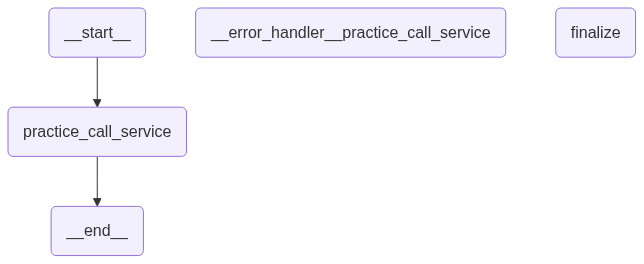

In [12]:
from langgraph.errors import NodeError
from langgraph.types import Command


class RecoveryState(TypedDict):
    status: str
    error_message: str


recovery_count = {"attempts": 0, "handled": 0}


def practice_call_service(state):
    recovery_count["attempts"] += 1
    print(f"조회 시도 - 연결 실패")
    raise ConnectionError("외부 조회 서비스 연결 실패")

def service_error_handler(state: RecoveryState, error: NodeError) -> Command:
    recovery_count["handled"] += 1
    print("error_handler 실행: 실패 상태를 기록하고 finalize로 이동")
    return Command(
        update={"status": "failed", "error_message": f"{error.node}: {error.error}"},
        goto="finalize",
    )


def finalize(state: RecoveryState):
    print(f"finalize 실행: status={state['status']}")
    return {"status": state["status"]}


recovery_builder = StateGraph(RecoveryState)
recovery_builder.add_node(
    "practice_call_service",
    practice_call_service,
    retry_policy=RetryPolicy(
        initial_interval=1.0,
        backoff_factor=1.5,
        max_interval=1.0,
        max_attempts=3,
        jitter=False,
        retry_on=ConnectionError,
    ),
    error_handler=service_error_handler,
)
recovery_builder.add_node("finalize", finalize)
recovery_builder.add_edge(START, "practice_call_service")
recovery_builder.add_edge("finalize", END)
recovery_graph = recovery_builder.compile()

display(Image(recovery_graph.get_graph().draw_mermaid_png()))

In [13]:
recovery_result = recovery_graph.invoke({})
print("결과:", recovery_result)
print("호출 횟수:", recovery_count)

조회 시도 - 연결 실패
조회 시도 - 연결 실패
조회 시도 - 연결 실패
error_handler 실행: 실패 상태를 기록하고 finalize로 이동
finalize 실행: status=failed
결과: {'status': 'failed', 'error_message': 'practice_call_service: 외부 조회 서비스 연결 실패'}
호출 횟수: {'attempts': 3, 'handled': 1}
